# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Elma Nurul Fatika  
**NIM:** 122140069  

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


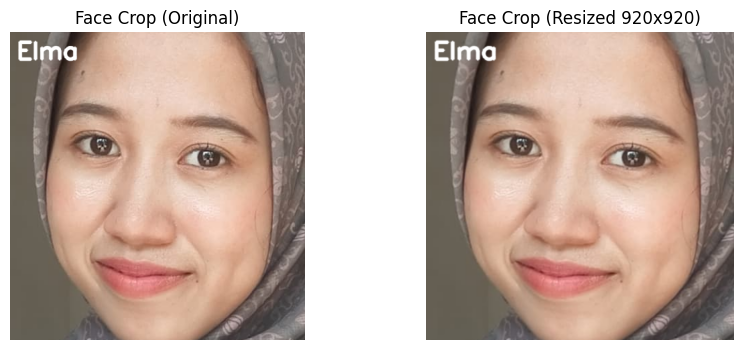

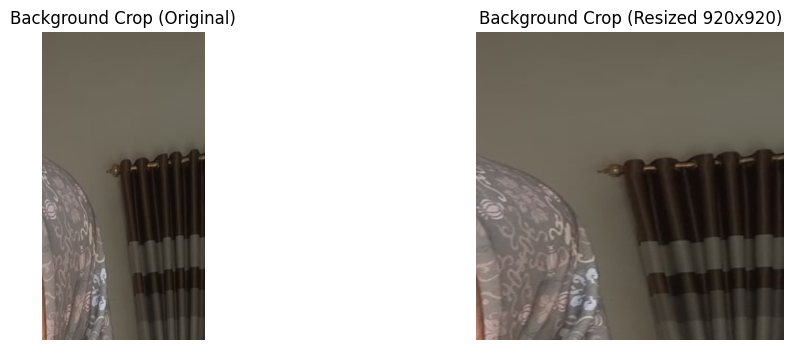

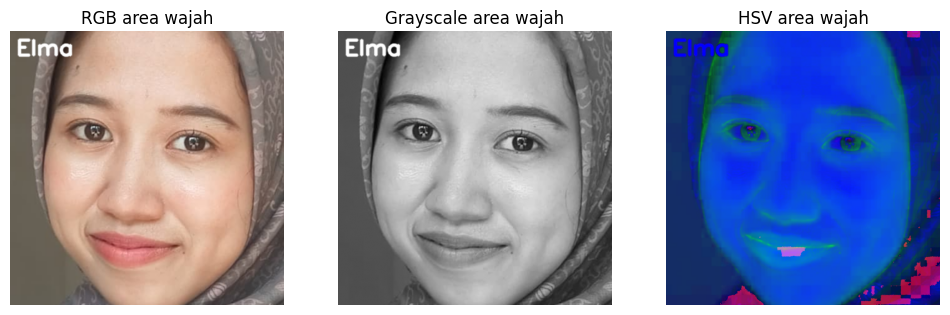

In [75]:
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('assets_ws4/selfie2.jpg')

# Tentukan koordinat crop area wajah (misal: x1, y1, x2, y2)
x1, y1, x2, y2 = 279, 325, 719, 785

# Crop kotak persegi area wajah
face_crop = img[y1:y2, x1:x2]

# Tambahkan anotasi teks di atas kepala
cv2.putText(face_crop, 
            "Elma",
            (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (255, 255, 255), 
            3,
            cv2.LINE_AA)

# Resize crop area wajah menjadi 920x920 piksel
face_crop_resized = cv2.resize(face_crop, (920, 920))

#output face crop + resize
plt.figure(figsize=(10, 4))

# face crop original
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
plt.title("Face Crop (Original)")
plt.axis("off")

# face crop resized
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(face_crop_resized, cv2.COLOR_BGR2RGB))
plt.title("Face Crop (Resized 920x920)")
plt.axis("off")

plt.show()

# Tentukan koordinat crop area background (misal: x1, y1, x2, y2)
x1, y1, x2, y2 = 663, 0, 959, 562

# crop kotak persegi panjang area background
background_crop = img[y1:y2, x1:x2]

# Resize crop area background menjadi 920x920 piksel
background_crop_resized = cv2.resize(background_crop, (920, 920))


# output background crop + resize
plt.figure(figsize=(12, 4))

# background crop original
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(background_crop, cv2.COLOR_BGR2RGB))
plt.title("Background Crop (Original)")
plt.axis("off")

# background crop resized
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(background_crop_resized, cv2.COLOR_BGR2RGB))
plt.title("Background Crop (Resized 920x920)")
plt.axis("off")

plt.show()

# konversi gambar menjadi grayscale dan HSV ketiganya berdampingan
face_crop_gray = cv2.cvtColor(face_crop_resized, cv2.COLOR_BGR2GRAY)
face_crop_hsv = cv2.cvtColor(face_crop_resized, cv2.COLOR_BGR2HSV)

# Tampilkan hasil grayscale dan HSV wajah berdampingan
plt.figure(figsize=(12, 4))

# RGB asli
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(face_crop_resized, cv2.COLOR_BGR2RGB))
plt.title("RGB area wajah")
plt.axis("off")

# Grayscale
plt.subplot(1, 3, 2)
plt.imshow(face_crop_gray, cmap='gray')
plt.title("Grayscale area wajah")
plt.axis("off")

# HSV ditampilkan langsung tanpa convert ke RGB
plt.subplot(1, 3, 3)
plt.imshow(face_crop_hsv)
plt.title("HSV area wajah")
plt.axis("off")

plt.show()


Penjelasan efek cropping dan perubahan warna:
* efek cropping menyebabkan gambar menjadi fokus di area tertentu, jadi karena cropping dilakukan untuk area wajah dan background maka hasilnya adalah potongan dari area wajah dan background yang diminta (sesuai ukuran).
* perubahan warna pada grayscale mengakibatkan gambar hanya memiliki dua warna, yaitu hitam dan putih sehingga kita tidak bisa menebak warna lain yang terdapat pada gambar, kemungkinan besarnya hanya bisa menebak sisi bagian gelap dan terangnya saja. sedangkan perubahan warna HSV yang menekankan pada Hue, Saturation dan Value membuat karakteristik warnanya dapat dianalisis lebih spesifik.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


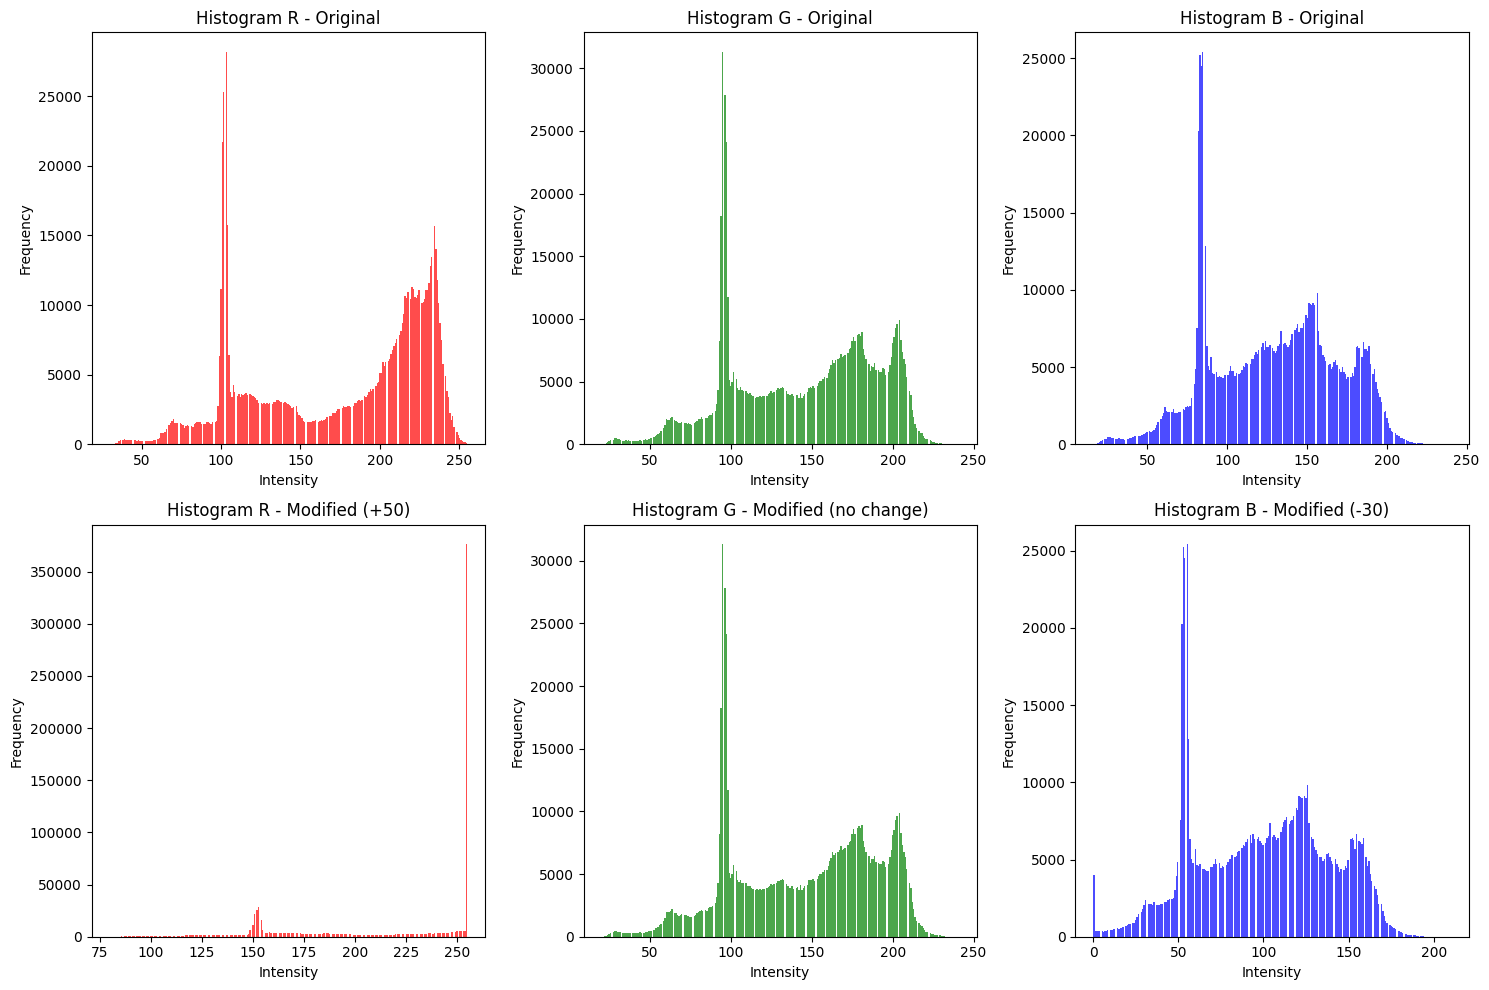

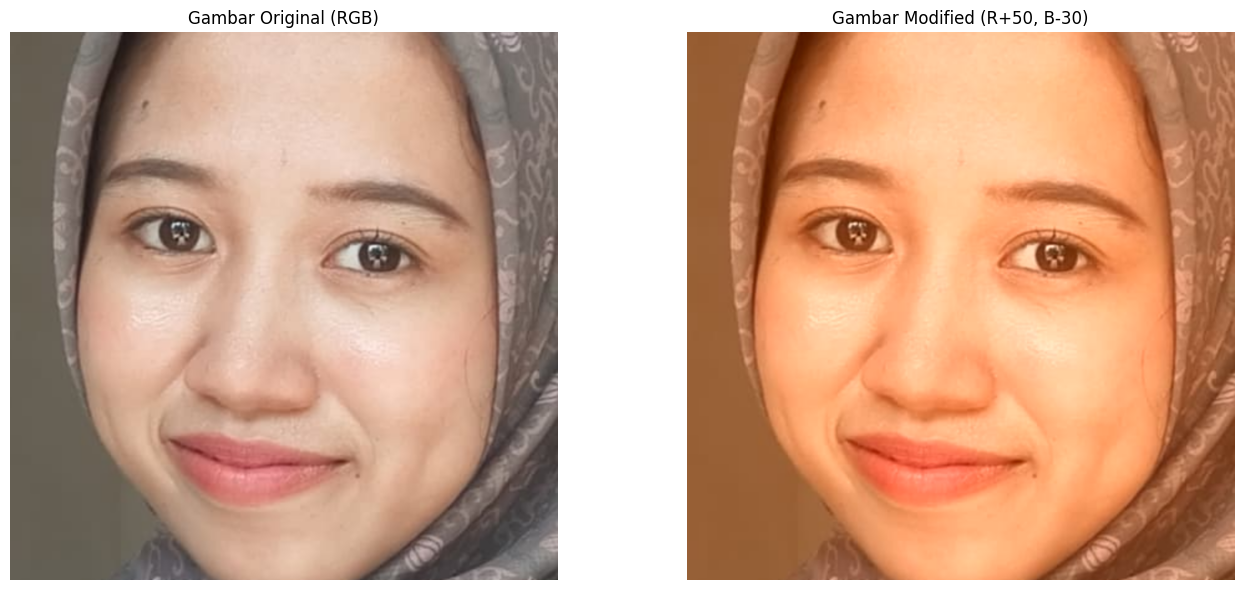

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image and recreate face_crop from Soal 1
img = cv2.imread('assets_ws4/selfie2.jpg')
x1, y1, x2, y2 = 279, 325, 719, 785
face_crop = img[y1:y2, x1:x2]
face_crop = cv2.resize(face_crop, (920, 920))  # Resize as in Soal 1

# Konversi dari BGR ke RGB
face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
R_original = face_rgb[:, :, 0].astype(float)
G_original = face_rgb[:, :, 1].astype(float)
B_original = face_rgb[:, :, 2].astype(float)

# Manipulasi channel warna
# Naikkan intensitas channel merah sebanyak 50 poin (maksimum 255)
R_modified = np.clip(R_original + 50, 0, 255)

# Turunkan intensitas channel biru sebanyak 30 poin (minimum 0)
B_modified = np.clip(B_original - 30, 0, 255)

# G tidak diubah
G_modified = G_original

# Gabungkan kembali channel warna
rgb_modified = np.stack([R_modified, G_modified, B_modified], axis=2).astype(np.uint8)

# Simpan gambar hasil modifikasi dalam format .png
cv2.imwrite('results_ws4/face_rgb_modified.png', cv2.cvtColor(rgb_modified, cv2.COLOR_RGB2BGR))

# Tampilkan histogram per channel untuk gambar asli
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Histogram gambar asli
axes[0, 0].hist(R_original.flatten(), bins=256, color='red', alpha=0.7)
axes[0, 0].set_title('Histogram R - Original')
axes[0, 0].set_xlabel('Intensity')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(G_original.flatten(), bins=256, color='green', alpha=0.7)
axes[0, 1].set_title('Histogram G - Original')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')

axes[0, 2].hist(B_original.flatten(), bins=256, color='blue', alpha=0.7)
axes[0, 2].set_title('Histogram B - Original')
axes[0, 2].set_xlabel('Intensity')
axes[0, 2].set_ylabel('Frequency')

# Histogram gambar hasil modifikasi
axes[1, 0].hist(R_modified.flatten(), bins=256, color='red', alpha=0.7)
axes[1, 0].set_title('Histogram R - Modified (+50)')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(G_modified.flatten(), bins=256, color='green', alpha=0.7)
axes[1, 1].set_title('Histogram G - Modified (no change)')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Frequency')

axes[1, 2].hist(B_modified.flatten(), bins=256, color='blue', alpha=0.7)
axes[1, 2].set_title('Histogram B - Modified (-30)')
axes[1, 2].set_xlabel('Intensity')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Tampilkan perbandingan gambar asli dan hasil modifikasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(face_rgb)
axes[0].set_title('Gambar Original (RGB)')
axes[0].axis('off')

axes[1].imshow(rgb_modified)
axes[1].set_title('Gambar Modified (R+50, B-30)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Dampak perubahan RGB pada warna gambar
* Dampak dari perubahan RGB pada warna gambar yaitu gambarnya terlihat lebih cerah, hangat dan berwarna oren/kemerahan karena channelnya diubah menjadi R(+50) dan B(-30).

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


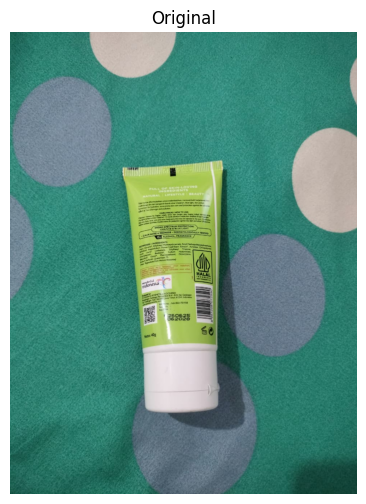

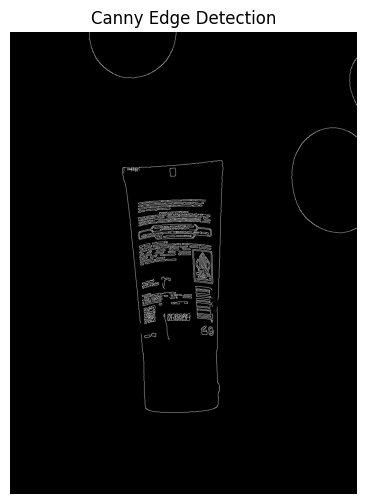

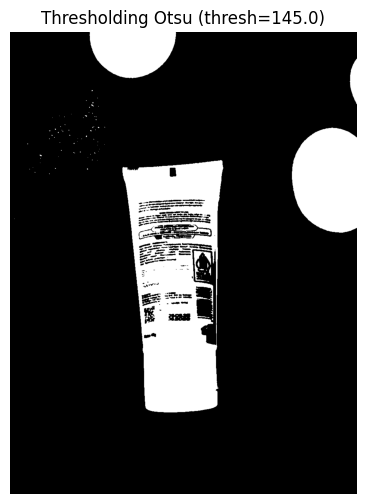

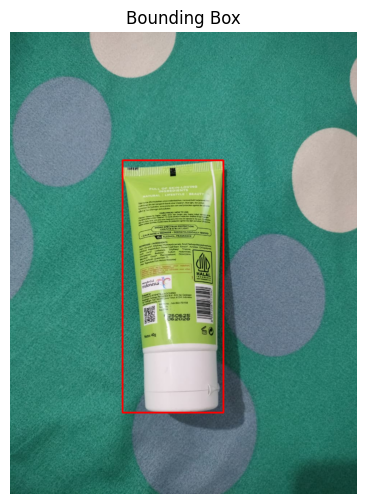

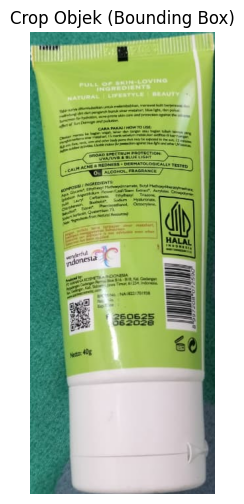

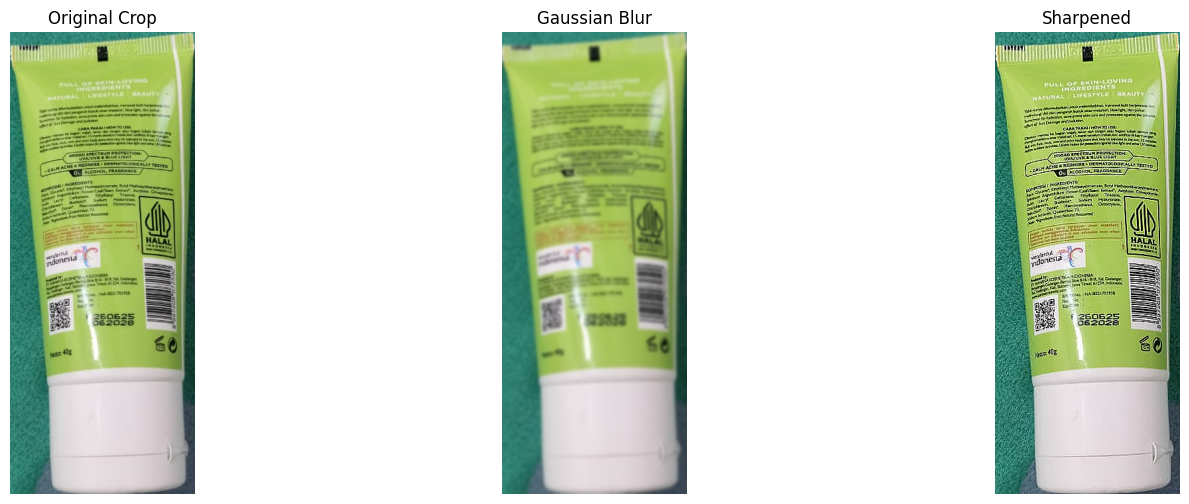

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#konfigurasi path
img_path = "assets_ws4/objek.jpg"
out_dir = Path("./result_ws4") 
out_dir.mkdir(parents=True, exist_ok=True)

#load image
src_bgr = cv2.imread(img_path)
if src_bgr is None:
    raise FileNotFoundError(f"Cannot open image at {img_path}")

#konversi dan preprocess
src_rgb = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (5,5), 0)

#gambar original
plt.figure(figsize=(6,6))
plt.imshow(src_rgb)
plt.title("Original")
plt.axis("off")
plt.savefig(out_dir / "original.png", bbox_inches='tight')
plt.show()

#edge detection (Canny)
edges = cv2.Canny(gray_blur, 100, 200)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.savefig(out_dir / "edges.png", bbox_inches='tight')
plt.show()

# #thresholding menggunakan otsu
ret_otsu, thresh_otsu = cv2.threshold(gray_blur, 0, 255,
                                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f"Thresholding Otsu (thresh={ret_otsu:.1f})")
plt.axis("off")
plt.savefig(out_dir / "thresh_otsu.png", bbox_inches='tight')
plt.show()

#bounding box
contours, _ = cv2.findContours(thresh_otsu, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    raise RuntimeError("No contours found. Adjust threshold or image.")

largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)

boxed = src_rgb.copy()
cv2.rectangle(boxed, (x, y), (x+w, y+h), (255,0,0), 3)

plt.figure(figsize=(6,6))
plt.imshow(boxed)
plt.title("Bounding Box")
plt.axis("off")
plt.savefig(out_dir / "bbox.png", bbox_inches='tight')
plt.show()

#crop hasil bounding box
crop = src_rgb[y:y+h, x:x+w]

plt.figure(figsize=(6,6))
plt.imshow(crop)
plt.title("Crop Objek (Bounding Box)")
plt.axis("off")
plt.savefig(out_dir / "crop.png", bbox_inches='tight')
plt.show()

#filter blur dan sharpen
blurred = cv2.GaussianBlur(crop, (11,11), 0)
kernel_sharp = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
sharpened = cv2.filter2D(crop, -1, kernel_sharp)

# simpan masing-masing
cv2.imwrite(str(out_dir / "blur.png"), cv2.cvtColor(blurred, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(out_dir / "sharpen.png"), cv2.cvtColor(sharpened, cv2.COLOR_RGB2BGR))

# tampilkan dibandingkan
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(crop)
plt.title("Original Crop")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blurred)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sharpened)
plt.title("Sharpened")
plt.axis("off")

plt.savefig(out_dir / "comparison.png", bbox_inches='tight')
plt.show()


Penjelasan efek filter pada objek:
- Blur:

  * filter ini berguna untuk menghaluskan tekstur dan mengurangi detail-detail halus pada permukaan objek (noise). jadi tepi-tepinya menjadi halus dan kurang tajam, filter ini berguna untuk menonjolkan bentuk umum dari objeknya.

- Sharpen:
  * filter sharpen ini meningkatkan kontras bagian tepi-tepi sehingga detailnya lebih tajam (tulisan, garis tepi kemasan). detail-detail kecil menjadi terlihat lebih jelas, dan filter ini bisa untuk membuat analisis lebih detail (menajamkan teks kecil di kemasan) tapi noisenya bisa lebih kuat.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

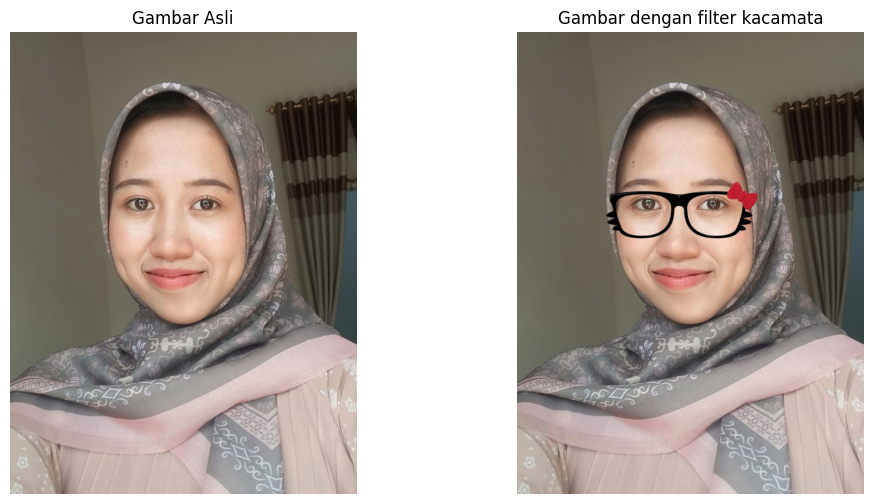

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp 

# Load gambar
img_path = 'assets_ws4/selfie1.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load filter kacamata
filter_path = 'assets_ws4/filter.png'
glasses_png = cv2.imread(filter_path, cv2.IMREAD_UNCHANGED)

if glasses_png is None:
    raise FileNotFoundError("Filter PNG tidak ditemukan!")

# Convert BGR ke RGB
glasses_png[:, :, :3] = cv2.cvtColor(glasses_png[:, :, :3], cv2.COLOR_BGR2RGB)

# Setup MediaPipe FaceMesh
mp_face = mp.solutions.face_mesh
face_mesh = mp_face.FaceMesh(static_image_mode=True, refine_landmarks=True, max_num_faces=1)

output = img_rgb.copy()

# Fungsi overlay PNG dengan alpha channel
def overlay_png(background, overlay, pos_x, pos_y):
    h, w = overlay.shape[:2]

    # Cegah keluar batas gambar
    if pos_x + w > background.shape[1]:
        w = background.shape[1] - pos_x
        overlay = overlay[:, :w]
    if pos_y + h > background.shape[0]:
        h = background.shape[0] - pos_y
        overlay = overlay[:h, :]

    alpha = overlay[:, :, 3] / 255.0
    rgb = overlay[:, :, :3]

    for c in range(3):
        background[pos_y:pos_y+h, pos_x:pos_x+w, c] = (
            alpha * rgb[:, :, c] +
            (1 - alpha) * background[pos_y:pos_y+h, pos_x:pos_x+w, c]
        )
    return background


# penyesuaian manual posisi dan skala kacamata
offset_x = 0      # geser kiri(-) / kanan(+)
offset_y = 20      # geser atas(-) / bawah(+)

scale = 2.5      # ukuran kacamata

# Proses FaceMesh
results = face_mesh.process(img_rgb)

if results.multi_face_landmarks:

    for face_landmarks in results.multi_face_landmarks:

        h, w, _ = img_rgb.shape

        # Landmark mata kiri (133) dan mata kanan (362)
        left_eye = face_landmarks.landmark[133]
        right_eye = face_landmarks.landmark[362]

        # Konversi normalisasi → piksel
        lx, ly = int(left_eye.x * w), int(left_eye.y * h)
        rx, ry = int(right_eye.x * w), int(right_eye.y * h)

        # Hitung posisi tengah mata
        eye_center_x = (lx + rx) // 2
        eye_center_y = (ly + ry) // 2

        # Hitung jarak mata → ukuran kacamata
        eye_distance = int(np.linalg.norm([lx - rx, ly - ry]))
        glasses_width = int(eye_distance * 2.0 * scale)

        aspect_ratio = glasses_png.shape[0] / glasses_png.shape[1]
        glasses_height = int(glasses_width * aspect_ratio)

        # Posisi kacamata (centered)
        glasses_x = eye_center_x - glasses_width // 2
        glasses_y = eye_center_y - glasses_height // 2

        # Terapkan manual offset
        glasses_x += offset_x
        glasses_y += offset_y

        # Resize filter
        resized_glasses = cv2.resize(glasses_png, (glasses_width, glasses_height))

        # Pasang overlay
        output = overlay_png(output, resized_glasses, glasses_x, glasses_y)


# Tampilkan hasil
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Gambar dengan filter kacamata")
plt.axis("off")

plt.show()


Penjelasan cara menghitung overlay : 

posisi overlay kacamata dihitung menggunakan titik landmark mata kiri dan kanan yang diperoleh dari deteksi wajah. kemudian titik tengaah diantara kedua mata untuk pusatnya. lebarnya kacamata dihitung sesuai jarak kedua matanya, untuk tingginya disesuaikan dengan rasio asli dari gambar kacamatanya. setelah semuanya dihitung dan ditentukan untuk mengubah posisi (ngepasinnya) di sesuaikan menggunakan offset manual agar pas di mukanya.

Tantangan :

python saya tiba-tiba tidak bisa menggunakan mediapipe, saya sudah coba menginstall ulang namun tetap eror, jadi saya tanya gpt dan memperbaikinya, sedikit bingung karena di terminal vs codenya masih eror, jadi harus menggunakan CMD/powershell. tapi sudah teratasi (kurang lebih 30 menit) dan sudah bisa menggunakan mediapipe. (padahal python saya versi yang sama dengan saran pak martin).

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

C:\Users\Elma\AppData\Local\Temp\ipykernel_12340\170544259.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


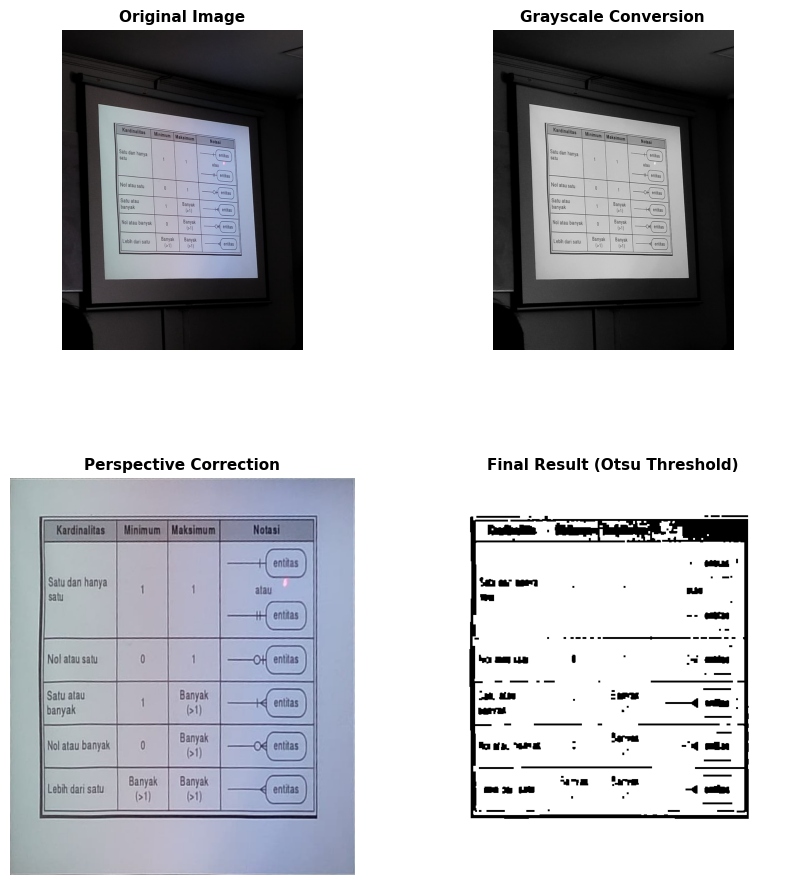

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#konfigurasi path
img_path = "assets_ws4/tugas.jpg"
out_dir = Path("./result_ws4")
out_dir.mkdir(parents=True, exist_ok=True)

#opsi titik manual
#Format: [[x_tl,y_tl], [x_tr,y_tr], [x_br,y_br], [x_bl,y_bl]]
src_pts_manual = None

#load image
src_bgr = cv2.imread(img_path)
if src_bgr is None:
    raise FileNotFoundError(f"Cannot open image at {img_path}")
src_rgb = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)

#konversi grayscale
gray = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2GRAY)

#perspective correction (manual jika ada, auto-detect jika tidak)
def order_points(pts):
    pts = np.array(pts, dtype="float32")
    rect = np.zeros((4,2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

h_img, w_img = gray.shape

if src_pts_manual is not None:
    src_pts = order_points(src_pts_manual)
else:
    # coba auto-detect via contour pada versi enhanced grayscale
    tmp = cv2.GaussianBlur(gray, (5,5), 0)
    _, th_tmp = cv2.threshold(tmp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kern = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    th_tmp = cv2.morphologyEx(th_tmp, cv2.MORPH_CLOSE, kern, iterations=1)
    contours, _ = cv2.findContours(th_tmp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        peri = cv2.arcLength(largest, True)
        approx = cv2.approxPolyDP(largest, 0.02 * peri, True)
        if approx.shape[0] == 4:
            src_pts = order_points(approx.reshape(4,2))
        else:
            x,y,w,h = cv2.boundingRect(largest)
            src_pts = np.array([[x,y],[x+w,y],[x+w,y+h],[x,y+h]], dtype=np.float32)
            src_pts = order_points(src_pts)
    else:
        # fallback ke seluruh gambar
        src_pts = np.array([[0,0],[w_img-1,0],[w_img-1,h_img-1],[0,h_img-1]], dtype=np.float32)

# hitung ukuran target warp
def dist(a,b):
    return np.linalg.norm(a-b)

width = int(max(dist(src_pts[0], src_pts[1]), dist(src_pts[2], src_pts[3])))
height = int(max(dist(src_pts[0], src_pts[3]), dist(src_pts[1], src_pts[2])))

# clamp ukuran agar tidak terlalu besar
max_allowed = 2000
width = max(100, min(width, max_allowed))
height = max(100, min(height, max_allowed))

dst_pts = np.array([[0,0],[width-1,0],[width-1,height-1],[0,height-1]], dtype=np.float32)

M = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped_bgr = cv2.warpPerspective(src_bgr, M, (width, height),
                                 flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_CONSTANT,
                                 borderValue=(0,0,0))
warped_rgb = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB)
warped_gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)

# crop margin hitam kecil (trim background black area)
mask_nonblack = (warped_gray > 5)
coords = np.column_stack(np.where(mask_nonblack))
if coords.size:
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    pad = 4
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(warped_gray.shape[0]-1, y1 + pad)
    x1 = min(warped_gray.shape[1]-1, x1 + pad)
    warped_bgr = warped_bgr[y0:y1+1, x0:x1+1]
    warped_rgb = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB)
    warped_gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)
    width = warped_gray.shape[1]
    height = warped_gray.shape[0]

#otsu thresholding pada hasil warp
_, th_otsu = cv2.threshold(
    warped_gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

#bersihkan noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
th_clean = cv2.morphologyEx(th_otsu, cv2.MORPH_OPEN, kernel, iterations=1)
th_clean = cv2.morphologyEx(th_clean, cv2.MORPH_CLOSE, kernel, iterations=1)

#simpan hasil
cv2.imwrite(str(out_dir / "warped.png"), cv2.cvtColor(warped_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(out_dir / "otsu_threshold.png"), th_clean)

#plot grid langkah-langkah
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10,11))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.25], hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0,0])   # top-left
ax2 = fig.add_subplot(gs[0,1])   # top-right
ax3 = fig.add_subplot(gs[1,0])   # bottom-left (lebih besar)
ax4 = fig.add_subplot(gs[1,1])   # bottom-right (lebih besar)

#
title_font = {'fontsize':11, 'fontweight':'bold'}

ax1.imshow(src_rgb)
ax1.set_title("Original Image", fontdict=title_font)
ax1.axis('off')

ax2.imshow(gray, cmap='gray')
ax2.set_title("Grayscale Conversion", fontdict=title_font)
ax2.axis('off')

ax3.imshow(warped_rgb)
ax3.set_title("Perspective Correction", fontdict=title_font)
ax3.axis('off')

ax4.imshow(th_clean, cmap='gray')
ax4.set_title("Final Result (Otsu Threshold)", fontdict=title_font)
ax4.axis('off')

plt.tight_layout()
out_path = out_dir / "result_grid_steps.png"
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()


Fungsi dari masing-masing tahapan
* tahap grayscale : tahap ini berfungsi untuk mengecilkan/menyederhanakan informasi dari gambar agar tahap berikutnya menjadi lebih mudah dan cepat karena telah di kurangi dimensi warnanya.
* tahap prespective correction : tahap ini berfungsi untuk membuat objek yang miring dan tidak presisi menjadi presisi (objeknya miring dan diperbaiki agar menjadi pas, lurus, dan enak dilihat).
* tahap tresholding menggunakan otsu : tahap ini berfungsi untuk menonjolkan objek utamanya agar gambar terlihat leih clear. sehingga gambarnya lebih jelas (di tonjolkan bagian garis dan text).

teknik ini meningkatkan kualitas visual citra karena tahapan-tahapannya membuat gambarnya leih jelas dan fokus di objek utamanya.

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.

bantuan dan referensi: 
* CHAT GPT : https://chatgpt.com/c/69188002-b940-8322-b2e1-11918a8f1154
* https://chatgpt.com/c/691a6b17-59e4-8321-a988-1444987b00fb
* Pinterest : https://id.pinterest.com/pin/53198839343077207/
